# StaySure Hotel Cancellation ML
## Milestone 7 — Model Explainability, Error Analysis, and Responsible AI

**Business goal:** explain the frozen Milestone 6 cancellation policy, identify where it makes mistakes, and document the limitations that must accompany any operational use.

This notebook does **not** retrain the model or change the selected threshold. It uses the saved tuned model bundle and chronological validation period. The future test set remains sealed.

### Main outputs

- `reports/milestone_07_global_shap_importance.csv` — grouped global SHAP importance
- `reports/milestone_07_cohort_performance.csv` — validation metrics across selected booking cohorts
- `reports/milestone_07_error_cases.csv` — highest-confidence false positives and false negatives
- `reports/milestone_07_responsible_ai_review.csv` — risks, harms, and mitigations
- `reports/milestone_07_explainability_summary.csv` — frozen-policy and explanation summary


### What you should be able to explain afterward

1. The difference between global and local explanations.
2. What a SHAP value means for a cancellation prediction.
3. Why one-hot encoded columns should be regrouped into source features.
4. How false positives and false negatives create different operational risks.
5. Why subgroup metrics are diagnostic evidence, not proof of fairness.
6. Why feature importance and SHAP do not establish causality.
7. Why the final test period must remain sealed during explainability work.


## Before running the notebook

Milestone 7 adds SHAP as a project dependency. From the activated `.venv`, install the stable version used by this notebook:

```powershell
python -m pip install shap==0.52.0
```

Also add this line to `requirements.txt`:

```text
shap==0.52.0
```


## 1. Setup


In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score, precision_score,
    recall_score, roc_auc_score,
)

try:
    import shap
except ImportError as exc:
    raise ImportError(
        "Install the Milestone 7 dependency with: "
        "python -m pip install shap==0.52.0"
    ) from exc

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
RANDOM_STATE = 42
print("Libraries loaded. SHAP version:", shap.__version__)


Libraries loaded. SHAP version: 0.49.1


In [2]:
cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
CLEAN_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "hotel_bookings_clean.csv"
PREPROCESSOR_PATH = PROJECT_ROOT / "models" / "preprocessing_pipeline.joblib"
TUNED_BUNDLE_PATH = PROJECT_ROOT / "models" / "random_forest_tuned_bundle.joblib"
FEATURE_MANIFEST_PATH = PROJECT_ROOT / "reports" / "milestone_03_feature_manifest.csv"
REPORTS_DIR = PROJECT_ROOT / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
print("Project root:", PROJECT_ROOT)


Project root: C:\Users\theko\ML_Projects\staysure-hotel-cancellation-ml


## 2. Recreate the established validation period


In [3]:
required_paths = [
    CLEAN_DATA_PATH,
    PREPROCESSOR_PATH,
    TUNED_BUNDLE_PATH,
    FEATURE_MANIFEST_PATH,
]
for required_path in required_paths:
    if not required_path.exists():
        raise FileNotFoundError(
            f"Required earlier-milestone artifact not found: {required_path}"
        )

df = pd.read_csv(CLEAN_DATA_PATH)
manifest = pd.read_csv(FEATURE_MANIFEST_PATH)
FEATURE_COLUMNS = manifest["source_feature"].tolist()
TARGET = "is_canceled"

month_number = {month: number for number, month in enumerate([
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December",
], start=1)}
df["arrival_date"] = pd.to_datetime({
    "year": df["arrival_date_year"],
    "month": df["arrival_date_month"].map(month_number),
    "day": df["arrival_date_day_of_month"],
})
df = df.sort_values("arrival_date").reset_index(drop=True)

valid_df = df[
    (df["arrival_date"] > "2017-02-10")
    & (df["arrival_date"] <= "2017-05-21")
].copy()
test_row_count = (df["arrival_date"] > "2017-05-21").sum()

X_valid = valid_df[FEATURE_COLUMNS].copy()
y_valid = valid_df[TARGET].copy()

print("Validation:", X_valid.shape, f"cancellation rate={y_valid.mean():.2%}")
print("Future test rows still sealed:", test_row_count)


Validation: (17758, 27) cancellation rate=39.47%
Future test rows still sealed: 17869


The test period is counted only to confirm the chronological boundary. This notebook never creates a test feature matrix, target vector, prediction, explanation, or metric.


## 3. Load the frozen Milestone 6 policy


In [4]:
preprocessor = joblib.load(PREPROCESSOR_PATH)
tuned_bundle = joblib.load(TUNED_BUNDLE_PATH)
tuned_model = tuned_bundle["model"]
selected_threshold = float(tuned_bundle["threshold"])

assert tuned_bundle["feature_columns"] == FEATURE_COLUMNS

X_valid_ready = preprocessor.transform(X_valid)
transformed_feature_names = np.asarray(preprocessor.get_feature_names_out())

assert X_valid_ready.shape[0] == len(y_valid)
assert X_valid_ready.shape[1] == len(transformed_feature_names)
assert tuned_model.n_features_in_ == X_valid_ready.shape[1]

print("Validation matrix:", X_valid_ready.shape)
print("Frozen operating threshold:", round(selected_threshold, 2))
print("Frozen parameters:", tuned_bundle["selected_params"])


Validation matrix: (17758, 522)
Frozen operating threshold: 0.45
Frozen parameters: {'n_estimators': 80, 'max_depth': 15, 'min_samples_leaf': 10, 'max_features': 0.5}


## 4. Reproduce the frozen-policy validation results


In [5]:
valid_probabilities = tuned_model.predict_proba(X_valid_ready)[:, 1]
valid_predictions = (valid_probabilities >= selected_threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_valid, valid_predictions, labels=[0, 1]
).ravel()

frozen_policy_metrics = pd.DataFrame([{
    "threshold": selected_threshold,
    "accuracy": accuracy_score(y_valid, valid_predictions),
    "precision": precision_score(y_valid, valid_predictions, zero_division=0),
    "recall": recall_score(y_valid, valid_predictions, zero_division=0),
    "f1": f1_score(y_valid, valid_predictions, zero_division=0),
    "roc_auc": roc_auc_score(y_valid, valid_probabilities),
    "true_negatives": tn,
    "false_positives": fp,
    "false_negatives": fn,
    "true_positives": tp,
}])
display(frozen_policy_metrics.T)


,0
threshold,0.4500
accuracy,0.7942
precision,0.6926
recall,0.8606
f1,0.7675
roc_auc,0.9000
true_negatives,"8,072.0000"
false_positives,"2,677.0000"
false_negatives,977.0000
true_positives,"6,032.0000"


The numbers above are descriptive checks. They do not reopen model or threshold selection. Milestone 7 explains the already-selected policy.


## 5. Build a controlled SHAP explanation sample


### TODO 1 — Configure the explanation sample


In [6]:
# TODO 1: Explain 1,000 validation rows and use class index 1 for cancellation.
EXPLANATION_SAMPLE_SIZE = 1000
CANCELLATION_CLASS_INDEX = 1

if EXPLANATION_SAMPLE_SIZE is None or CANCELLATION_CLASS_INDEX is None:
    print("TODO 1: Set the sample size and cancellation class index.")
else:
    explanation_size = min(EXPLANATION_SAMPLE_SIZE, len(X_valid))
    explanation_positions = (
        pd.Series(np.arange(len(X_valid)))
        .sample(n=explanation_size, random_state=RANDOM_STATE)
        .sort_values()
        .to_numpy()
    )
    X_explain_ready = X_valid_ready[explanation_positions]
    X_explain_dense = (
        X_explain_ready.toarray()
        if hasattr(X_explain_ready, "toarray")
        else np.asarray(X_explain_ready)
    )
    print("Explanation sample:", X_explain_dense.shape)


Explanation sample: (1000, 522)


The sample is fixed with `random_state=42`. Approximate TreeSHAP is used for the global sample to keep runtime practical; exact TreeSHAP is used later for two local cases.


## 6. Calculate cancellation-class SHAP values


### TODO 2 — Extract the positive-class explanation


In [7]:
if "X_explain_dense" not in globals():
    print("Complete TODO 1 first.")
else:
    tree_explainer = shap.TreeExplainer(tuned_model)
    shap_output = tree_explainer(
        X_explain_dense,
        approximate=True,
        check_additivity=False,
    )

    if shap_output.values.ndim == 3:
        # TODO 2: Select the cancellation class from the last axis.
        cancellation_shap_values = shap_output.values[
            :, :, CANCELLATION_CLASS_INDEX
        ]
        cancellation_base_values = shap_output.base_values[
            :, CANCELLATION_CLASS_INDEX
        ]
    else:
        cancellation_shap_values = shap_output.values
        cancellation_base_values = shap_output.base_values

    if cancellation_shap_values is None or cancellation_base_values is None:
        print("TODO 2: Extract the cancellation-class SHAP values.")
    else:
        cancellation_explanation = shap.Explanation(
            values=cancellation_shap_values,
            base_values=cancellation_base_values,
            data=X_explain_dense,
            feature_names=transformed_feature_names,
        )
        print("Cancellation SHAP matrix:", cancellation_explanation.values.shape)


Cancellation SHAP matrix: (1000, 522)


<details>
<summary>Hint for TODO 2</summary>

For a binary classifier, recent SHAP versions return `(rows, features, classes)`. Select `[:, :, CANCELLATION_CLASS_INDEX]` for the values and `[:, CANCELLATION_CLASS_INDEX]` for the base values.
</details>


## 7. Global model explanation


### TODO 3 — Calculate mean absolute SHAP importance


In [8]:
if "cancellation_explanation" not in globals():
    print("Complete TODO 2 first.")
else:
    # TODO 3: Average the absolute SHAP values down the row axis.
    mean_abs_shap = np.abs(
        cancellation_explanation.values
    ).mean(axis=0)

    if mean_abs_shap is None:
        print("TODO 3: Calculate mean absolute SHAP importance.")
    else:
        transformed_shap_importance = (
            pd.DataFrame({
                "transformed_feature": transformed_feature_names,
                "mean_abs_shap": mean_abs_shap,
            })
            .sort_values("mean_abs_shap", ascending=False)
            .reset_index(drop=True)
        )
        display(transformed_shap_importance.head(15))


,transformed_feature,mean_abs_shap
0,country_PRT,0.1004
1,deposit_type_Non Refund,0.0986
2,total_of_special_requests,0.0969
3,market_segment_Online TA,0.0885
4,lead_time,0.0715
5,arrival_date_year,0.0486
6,deposit_type_No Deposit,0.0466
7,required_car_parking_spaces,0.0297
8,adr,0.0212
9,arrival_date_week_number,0.0208


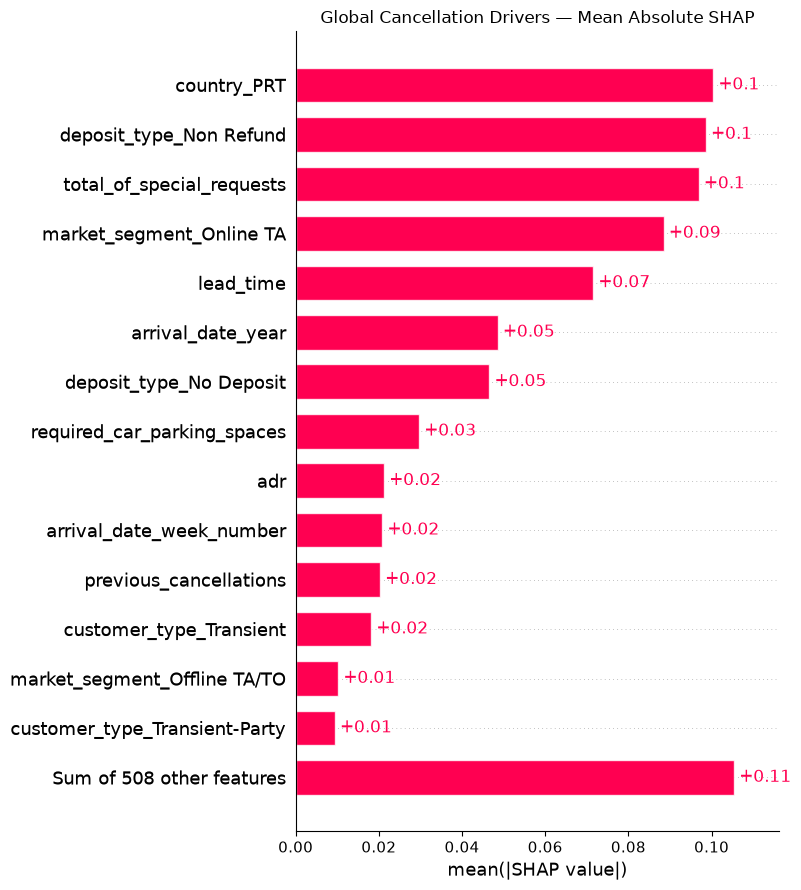

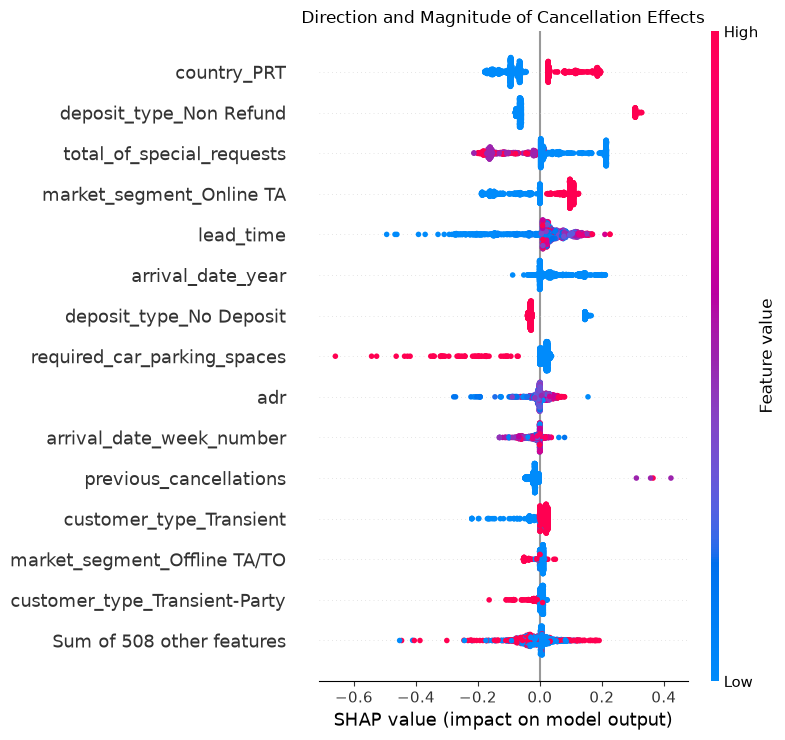

In [9]:
if "cancellation_explanation" not in globals():
    print("Complete TODO 2 first.")
else:
    shap.plots.bar(cancellation_explanation, max_display=15, show=False)
    plt.title("Global Cancellation Drivers — Mean Absolute SHAP")
    plt.tight_layout()
    plt.show()

    shap.plots.beeswarm(cancellation_explanation, max_display=15, show=False)
    plt.title("Direction and Magnitude of Cancellation Effects")
    plt.tight_layout()
    plt.show()


### How to read the plots

- The bar chart ranks features by average explanation magnitude.
- The beeswarm adds direction: points to the right increase predicted cancellation risk; points to the left decrease it.
- Color represents the transformed feature value, not whether the feature is good or bad.


## 8. Regroup one-hot columns into source features


In [10]:
def identify_source_feature(transformed_name, source_features):
    clean_name = transformed_name.split("__", 1)[-1]
    for source_feature in sorted(source_features, key=len, reverse=True):
        if clean_name == source_feature or clean_name.startswith(source_feature + "_"):
            return source_feature
    return "unmatched"


if "transformed_shap_importance" not in globals():
    print("Complete TODO 3 first.")
else:
    transformed_shap_importance["source_feature"] = [
        identify_source_feature(name, FEATURE_COLUMNS)
        for name in transformed_shap_importance["transformed_feature"]
    ]
    assert "unmatched" not in set(
        transformed_shap_importance["source_feature"]
    )

    grouped_shap_importance = (
        transformed_shap_importance
        .groupby("source_feature", as_index=False)
        .agg(
            mean_abs_shap=("mean_abs_shap", "sum"),
            transformed_columns=("transformed_feature", "count"),
        )
        .sort_values("mean_abs_shap", ascending=False)
        .reset_index(drop=True)
    )
    grouped_shap_importance["importance_share"] = (
        grouped_shap_importance["mean_abs_shap"]
        / grouped_shap_importance["mean_abs_shap"].sum()
    )
    display(grouped_shap_importance.head(15))


,source_feature,mean_abs_shap,transformed_columns,importance_share
0,deposit_type,0.1453,3,0.1848
1,country,0.1160,164,0.1476
2,market_segment,0.1085,8,0.1380
3,total_of_special_requests,0.0969,1,0.1232
4,lead_time,0.0715,1,0.0910
5,arrival_date_year,0.0486,1,0.0618
6,required_car_parking_spaces,0.0297,1,0.0377
7,customer_type,0.0279,4,0.0355
8,adr,0.0212,1,0.0270
9,arrival_date_week_number,0.0208,1,0.0265


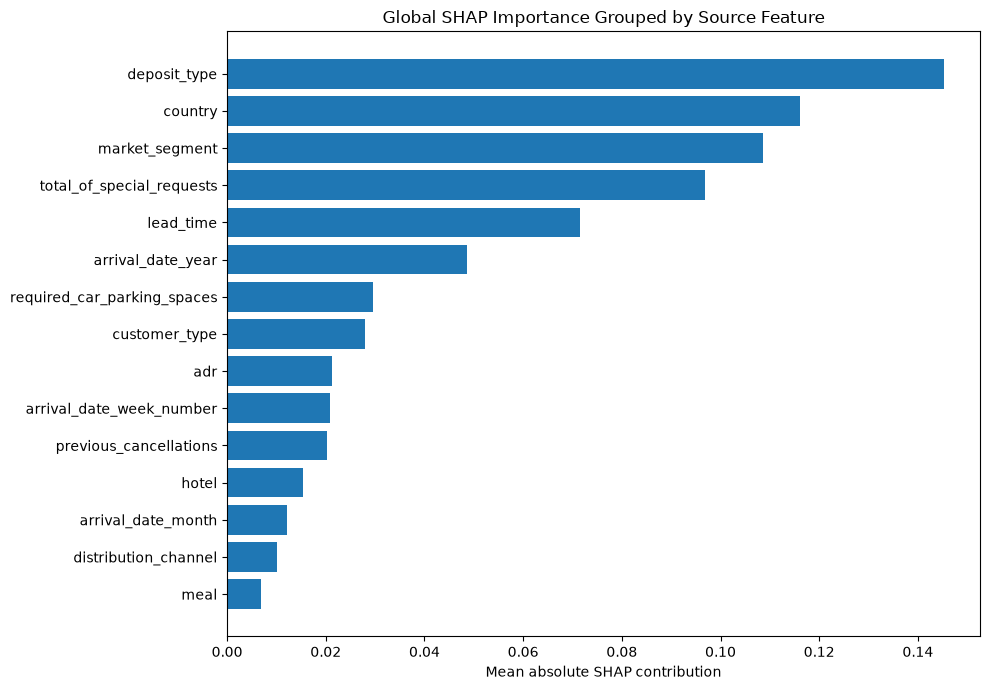

In [11]:
if "grouped_shap_importance" not in globals():
    print("Complete TODO 3 first.")
else:
    top_grouped = grouped_shap_importance.head(15).sort_values("mean_abs_shap")
    plt.figure(figsize=(10, 7))
    plt.barh(top_grouped["source_feature"], top_grouped["mean_abs_shap"])
    plt.title("Global SHAP Importance Grouped by Source Feature")
    plt.xlabel("Mean absolute SHAP contribution")
    plt.tight_layout()
    plt.show()


### TODO 4 — Interpret the global explanation

Identify the leading source features. Explain why importance is not causality and why an operational decision should not be based on SHAP alone.

## LEADING SOURCE FEATURE ANALYSIS
The leading source features were `deposit_type` (18.48% of total SHAP importance), `country` (14.76%), `market_segment` (13.80%), `total_of_special_requests` (12.32%), and `lead_time` (9.10%). These features had the largest average influence on the model’s cancellation predictions within the validation sample. However, SHAP importance describes how the model uses a feature; it does not prove that the feature causes cancellations. The observed importance may reflect correlations, historical booking policies, selection effects, or proxy relationships with other variables. Therefore, StaySure should not make operational decisions based on SHAP alone. The findings should be combined with domain expertise, cohort-level performance checks, responsible-AI review, business impact analysis, and controlled testing before changing customer policies or interventions.

<details>
<summary>Suggested structure</summary>

The leading features have the largest average influence on the model's cancellation probabilities within the validation sample. This describes model behavior, not a causal effect. A high-impact feature may reflect historical policy, selection effects, or correlations with other variables. StaySure should combine these explanations with domain review and controlled business testing before changing policy.
</details>


## 9. Explain individual decisions


In [12]:
validation_results = valid_df[
    ["arrival_date", TARGET] + FEATURE_COLUMNS
].reset_index(drop=True).copy()
validation_results["predicted_probability"] = valid_probabilities
validation_results["predicted_class"] = valid_predictions

conditions = [
    (validation_results[TARGET] == 0) & (validation_results["predicted_class"] == 0),
    (validation_results[TARGET] == 0) & (validation_results["predicted_class"] == 1),
    (validation_results[TARGET] == 1) & (validation_results["predicted_class"] == 0),
    (validation_results[TARGET] == 1) & (validation_results["predicted_class"] == 1),
]
validation_results["error_type"] = np.select(
    conditions,
    ["true_negative", "false_positive", "false_negative", "true_positive"],
    default="unknown",
)
display(validation_results["error_type"].value_counts().to_frame("rows"))


,rows
error_type,
true_negative,8072
true_positive,6032
false_positive,2677
false_negative,977


High-confidence true positive


,case
is_canceled,1
predicted_class,1
predicted_probability,1.0000
error_type,true_positive


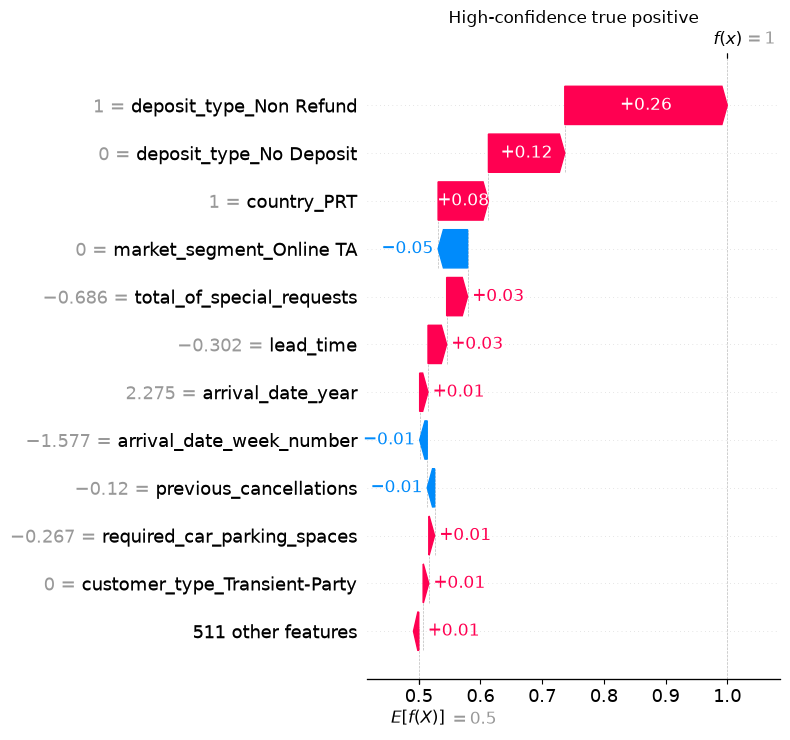

Missed cancellation


,case
is_canceled,1
predicted_class,0
predicted_probability,0.4500
error_type,false_negative


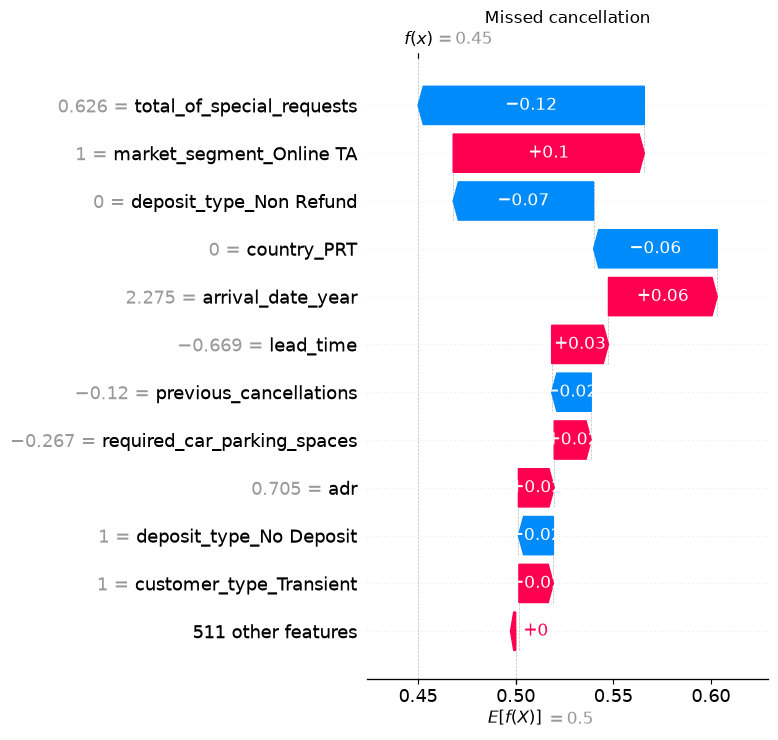

In [13]:
true_positive_position = int(
    validation_results.loc[
        validation_results["error_type"] == "true_positive",
        "predicted_probability",
    ].idxmax()
)
false_negative_position = int(
    validation_results.loc[
        validation_results["error_type"] == "false_negative",
        "predicted_probability",
    ].idxmax()
)

local_positions = [true_positive_position, false_negative_position]
local_labels = ["High-confidence true positive", "Missed cancellation"]
local_matrix = X_valid_ready[local_positions]
local_dense = (
    local_matrix.toarray()
    if hasattr(local_matrix, "toarray")
    else np.asarray(local_matrix)
)
local_output = tree_explainer(local_dense, check_additivity=False)

if local_output.values.ndim == 3:
    local_values = local_output.values[:, :, CANCELLATION_CLASS_INDEX]
    local_base_values = local_output.base_values[:, CANCELLATION_CLASS_INDEX]
else:
    local_values = local_output.values
    local_base_values = local_output.base_values

local_explanation = shap.Explanation(
    values=local_values,
    base_values=local_base_values,
    data=local_dense,
    feature_names=transformed_feature_names,
)

for index, label in enumerate(local_labels):
    print(label)
    display(
        validation_results.loc[
            local_positions[index],
            [TARGET, "predicted_class", "predicted_probability", "error_type"],
        ].to_frame("case")
    )
    shap.plots.waterfall(local_explanation[index], max_display=12, show=False)
    plt.title(label)
    plt.tight_layout()
    plt.show()


Local explanations show which transformed features moved one prediction away from its baseline. They can help investigate a decision, but they do not prove why the guest behaved a certain way.


## 10. Analyze false positives and false negatives


In [14]:
error_case_columns = [
    "arrival_date", TARGET, "predicted_class", "predicted_probability",
    "error_type", "hotel", "lead_time", "market_segment", "deposit_type",
    "customer_type", "adr", "total_of_special_requests",
]

false_positive_cases = (
    validation_results[validation_results["error_type"] == "false_positive"]
    .sort_values("predicted_probability", ascending=False)
    .head(100)[error_case_columns]
)
false_negative_cases = (
    validation_results[validation_results["error_type"] == "false_negative"]
    .sort_values("predicted_probability", ascending=True)
    .head(100)[error_case_columns]
)
error_cases = pd.concat(
    [false_positive_cases, false_negative_cases], ignore_index=True
)
display(error_cases.groupby("error_type").head(5))


,arrival_date,is_canceled,predicted_class,predicted_probability,error_type,hotel,lead_time,market_segment,deposit_type,customer_type,adr,total_of_special_requests
0,2017-04-22,0,1,0.9119,false_positive,Resort Hotel,267,Online TA,No Deposit,Transient,54.0000,0
1,2017-05-03,0,1,0.9111,false_positive,Resort Hotel,248,Online TA,No Deposit,Transient,54.0000,1
2,2017-05-03,0,1,0.9111,false_positive,Resort Hotel,248,Online TA,No Deposit,Transient,54.0000,1
3,2017-05-03,0,1,0.9111,false_positive,Resort Hotel,248,Online TA,No Deposit,Transient,54.0000,1
4,2017-05-03,0,1,0.9111,false_positive,Resort Hotel,248,Online TA,No Deposit,Transient,54.0000,1
100,2017-02-19,1,0,0.0160,false_negative,Resort Hotel,0,Direct,No Deposit,Transient-Party,80.0000,0
101,2017-05-08,1,0,0.0183,false_negative,City Hotel,0,Direct,No Deposit,Transient,139.5000,0
102,2017-03-15,1,0,0.0252,false_negative,City Hotel,6,Direct,No Deposit,Transient,100.6000,0
103,2017-03-15,1,0,0.0252,false_negative,City Hotel,6,Direct,No Deposit,Transient,100.6000,0
104,2017-03-03,1,0,0.0342,false_negative,Resort Hotel,8,Groups,No Deposit,Transient-Party,47.0000,0


**Operational meaning**

- A false positive may trigger unnecessary outreach, incentives, or inventory action.
- A false negative leaves StaySure exposed to an unanticipated cancellation.
- Reviewing both prevents a single aggregate metric from hiding asymmetric business harm.


## 11. Compare performance across booking cohorts


### TODO 5 — Select operational cohorts


In [15]:
# TODO 5: Analyze hotel, market segment, deposit type, and customer type.
COHORT_COLUMNS = [
    "hotel",
    "market_segment",
    "deposit_type",
    "customer_type"
]
MIN_COHORT_ROWS = 100

if COHORT_COLUMNS is None:
    print("TODO 5: Choose the four cohort columns.")
else:
    cohort_rows = []
    for cohort_column in COHORT_COLUMNS:
        for cohort_value, group in validation_results.groupby(
            cohort_column, dropna=False
        ):
            actual = group[TARGET].to_numpy()
            predicted = group["predicted_class"].to_numpy()
            group_tn, group_fp, group_fn, group_tp = confusion_matrix(
                actual, predicted, labels=[0, 1]
            ).ravel()
            cohort_rows.append({
                "cohort_feature": cohort_column,
                "cohort_value": cohort_value,
                "rows": len(group),
                "actual_cancellation_rate": actual.mean(),
                "predicted_cancellation_rate": predicted.mean(),
                "precision": precision_score(actual, predicted, zero_division=0),
                "recall": recall_score(actual, predicted, zero_division=0),
                "f1": f1_score(actual, predicted, zero_division=0),
                "false_positive_rate": (
                    group_fp / (group_fp + group_tn)
                    if group_fp + group_tn else np.nan
                ),
                "false_negative_rate": (
                    group_fn / (group_fn + group_tp)
                    if group_fn + group_tp else np.nan
                ),
                "true_negatives": group_tn,
                "false_positives": group_fp,
                "false_negatives": group_fn,
                "true_positives": group_tp,
            })

    cohort_performance = pd.DataFrame(cohort_rows)
    cohort_performance["stability_note"] = np.where(
        cohort_performance["rows"] < MIN_COHORT_ROWS,
        "small cohort — interpret cautiously",
        "reviewed cohort size",
    )
    display(
        cohort_performance
        .sort_values(["cohort_feature", "rows"], ascending=[True, False])
    )


,cohort_feature,cohort_value,rows,actual_cancellation_rate,predicted_cancellation_rate,precision,recall,f1,false_positive_rate,false_negative_rate,true_negatives,false_positives,false_negatives,true_positives,stability_note
14,customer_type,Transient,14383,0.4428,0.5533,0.6895,0.8615,0.7660,0.3083,0.1385,5543,2471,882,5487,reviewed cohort size
15,customer_type,Transient-Party,3031,0.2042,0.2418,0.7231,0.8562,0.7840,0.0842,0.1438,2209,203,89,530,reviewed cohort size
12,customer_type,Contract,265,0.0642,0.0604,0.8125,0.7647,0.7879,0.0121,0.2353,245,3,4,13,reviewed cohort size
13,customer_type,Group,79,0.0506,0.0253,1.0000,0.5000,0.6667,0.0000,0.5000,75,0,2,2,small cohort — interpret cautiously
9,deposit_type,No Deposit,15504,0.3068,0.4166,0.5855,0.7952,0.6745,0.2491,0.2048,8071,2677,974,3782,reviewed cohort size
10,deposit_type,Non Refund,2246,1.0000,1.0000,1.0000,1.0000,1.0000,NaN,0.0000,0,0,0,2246,reviewed cohort size
11,deposit_type,Refundable,8,0.8750,0.5000,1.0000,0.5714,0.7273,0.0000,0.4286,1,0,3,4,small cohort — interpret cautiously
0,hotel,City Hotel,12267,0.4453,0.5790,0.6838,0.8892,0.7731,0.3301,0.1108,4559,2246,605,4857,reviewed cohort size
1,hotel,Resort Hotel,5491,0.2817,0.2925,0.7316,0.7595,0.7453,0.1093,0.2405,3513,431,372,1175,reviewed cohort size
8,market_segment,Online TA,9192,0.4014,0.5887,0.5651,0.8287,0.6720,0.4277,0.1713,3149,2353,632,3058,reviewed cohort size


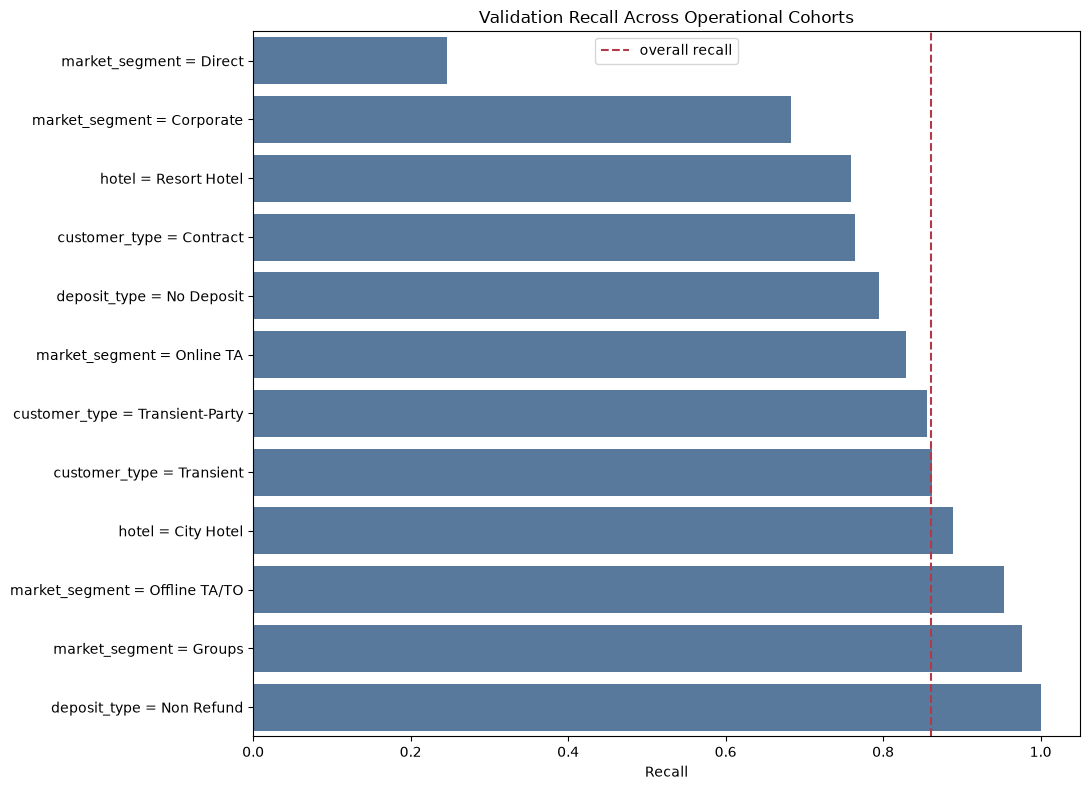

In [16]:
if "cohort_performance" not in globals():
    print("Complete TODO 5 first.")
else:
    stable_cohorts = cohort_performance[
        cohort_performance["rows"] >= MIN_COHORT_ROWS
    ].copy()
    plot_data = stable_cohorts.sort_values("recall")
    plot_data["cohort_label"] = (
        plot_data["cohort_feature"].astype(str)
        + " = "
        + plot_data["cohort_value"].astype(str)
    )
    plt.figure(figsize=(11, 8))
    sns.barplot(data=plot_data, x="recall", y="cohort_label", color="#4c78a8")
    plt.axvline(
        frozen_policy_metrics.loc[0, "recall"],
        color="#b23a48",
        linestyle="--",
        label="overall recall",
    )
    plt.title("Validation Recall Across Operational Cohorts")
    plt.xlabel("Recall")
    plt.ylabel("")
    plt.legend()
    plt.tight_layout()
    plt.show()


### Cohort interpretation

Look for large recall, false-negative-rate, or false-positive-rate differences. Small cohorts are unstable and should not support strong conclusions. These attributes are operational groupings, not a complete protected-class fairness audit.


## 12. Responsible-AI review


In [17]:
responsible_ai_review = pd.DataFrame([
    {
        "risk": "Historical policy bias",
        "evidence_to_review": "Features and target reflect past booking and cancellation policies.",
        "potential_harm": "The model may reproduce patterns created by earlier business rules.",
        "mitigation": "Review policy changes, document data-generating conditions, and monitor drift.",
        "status": "requires stakeholder review",
    },
    {
        "risk": "Proxy discrimination",
        "evidence_to_review": "Geography, channel, customer type, and pricing may proxy sensitive traits.",
        "potential_harm": "Interventions could burden some guest groups disproportionately.",
        "mitigation": "Complete a protected-class review with lawful, approved data before deployment.",
        "status": "not resolved by this dataset",
    },
    {
        "risk": "Uneven cohort errors",
        "evidence_to_review": "Compare recall, false-negative rate, and false-positive rate by cohort.",
        "potential_harm": "Some booking groups may receive less reliable predictions or more false alerts.",
        "mitigation": "Set monitoring thresholds and investigate material gaps with adequate sample sizes.",
        "status": "validation diagnostic completed",
    },
    {
        "risk": "Explanation misuse",
        "evidence_to_review": "SHAP explains model behavior but does not prove causality.",
        "potential_harm": "Teams may treat correlations as reasons to penalize or restrict guests.",
        "mitigation": "Use explanations for review and hypothesis generation, not automated penalties.",
        "status": "usage restriction required",
    },
    {
        "risk": "Data and concept drift",
        "evidence_to_review": "Booking behavior, channels, prices, and policies can change over time.",
        "potential_harm": "Performance may deteriorate after deployment.",
        "mitigation": "Monitor input distributions, cohort errors, calibration, and outcome metrics over time.",
        "status": "deployment monitoring required",
    },
])
display(responsible_ai_review)


,risk,evidence_to_review,potential_harm,mitigation,status
0,Historical policy bias,Features and target reflect past booking and c...,The model may reproduce patterns created by ea...,"Review policy changes, document data-generatin...",requires stakeholder review
1,Proxy discrimination,"Geography, channel, customer type, and pricing...",Interventions could burden some guest groups d...,"Complete a protected-class review with lawful,...",not resolved by this dataset
2,Uneven cohort errors,"Compare recall, false-negative rate, and false...",Some booking groups may receive less reliable ...,Set monitoring thresholds and investigate mate...,validation diagnostic completed
3,Explanation misuse,SHAP explains model behavior but does not prov...,Teams may treat correlations as reasons to pen...,Use explanations for review and hypothesis gen...,usage restriction required
4,Data and concept drift,"Booking behavior, channels, prices, and polici...",Performance may deteriorate after deployment.,"Monitor input distributions, cohort errors, ca...",deployment monitoring required


### TODO 6 — State the responsible-use boundary

Explain why this model should support human review and operational prioritization rather than automatically denying bookings, charging penalties, or changing contractual terms.

## DECISION SUPPORT REVIEW
This model should be used as a decision-support tool for human review and operational prioritization, not as an autonomous decision-maker. It learns from historical booking patterns that may contain policy bias, proxy relationships, and uneven error rates across booking cohorts. SHAP explains how features influence the model’s predictions, but it does not prove why a guest will cancel, and the available data does not constitute a complete fairness audit. StaySure may use the risk score to prioritize proportionate, non-punitive actions such as optional outreach, staffing, or inventory planning. The model should not independently deny bookings, impose fees or penalties, restrict services, or change contractual terms. Any consequential action should require documented human review, an override or appeal process, and ongoing monitoring for performance drift and unequal outcomes.

<details>
<summary>Suggested response</summary>

The model estimates cancellation risk from historical patterns and can make errors that are uneven across cohorts. Its explanations are associational rather than causal, and the dataset does not provide a complete fairness audit. The score should prioritize proportionate, reviewable outreach or planning actions. It should not independently deny service, impose penalties, or change a guest's contractual terms.
</details>


## 13. Build and save the Milestone 7 reports


In [18]:
if not all(name in globals() for name in [
    "grouped_shap_importance", "cohort_performance", "error_cases"
]):
    print("Complete TODOs 1–5 first.")
else:
    stable_with_recall = cohort_performance[
        (cohort_performance["rows"] >= MIN_COHORT_ROWS)
        & cohort_performance["recall"].notna()
    ]
    lowest_recall_row = stable_with_recall.sort_values("recall").iloc[0]
    top_features_text = ", ".join(
        grouped_shap_importance.head(5)["source_feature"].tolist()
    )
    explainability_summary = pd.DataFrame([{
        "model_type": type(tuned_model).__name__,
        "selected_threshold": selected_threshold,
        "validation_rows": len(validation_results),
        "explanation_sample_rows": len(explanation_positions),
        "validation_precision": frozen_policy_metrics.loc[0, "precision"],
        "validation_recall": frozen_policy_metrics.loc[0, "recall"],
        "validation_f1": frozen_policy_metrics.loc[0, "f1"],
        "validation_roc_auc": frozen_policy_metrics.loc[0, "roc_auc"],
        "top_five_source_features": top_features_text,
        "lowest_recall_cohort_feature": lowest_recall_row["cohort_feature"],
        "lowest_recall_cohort_value": lowest_recall_row["cohort_value"],
        "lowest_recall_cohort_rows": lowest_recall_row["rows"],
        "lowest_recall_cohort_recall": lowest_recall_row["recall"],
        "test_set_status": "sealed",
    }])
    display(explainability_summary.T)


,0
model_type,RandomForestClassifier
selected_threshold,0.4500
validation_rows,17758
explanation_sample_rows,1000
validation_precision,0.6926
validation_recall,0.8606
validation_f1,0.7675
validation_roc_auc,0.9000
top_five_source_features,"deposit_type, country, market_segment, total_o..."
lowest_recall_cohort_feature,market_segment


### TODO 7 — Save the reproducible reports


In [19]:
required_report_objects = [
    "grouped_shap_importance",
    "cohort_performance",
    "error_cases",
    "responsible_ai_review",
    "explainability_summary",
]

if any(name not in globals() for name in required_report_objects):
    print("Complete the earlier TODOs first.")
else:
    # TODO 7: Replace None with the grouped source-feature SHAP report.
    GLOBAL_SHAP_REPORT_TO_SAVE = grouped_shap_importance

    if GLOBAL_SHAP_REPORT_TO_SAVE is None:
        print("TODO 7: Choose the grouped SHAP report to save.")
    else:
        GLOBAL_SHAP_REPORT_TO_SAVE.to_csv(
            REPORTS_DIR / "milestone_07_global_shap_importance.csv", index=False
        )
        cohort_performance.to_csv(
            REPORTS_DIR / "milestone_07_cohort_performance.csv", index=False
        )
        error_cases.to_csv(
            REPORTS_DIR / "milestone_07_error_cases.csv", index=False
        )
        responsible_ai_review.to_csv(
            REPORTS_DIR / "milestone_07_responsible_ai_review.csv", index=False
        )
        explainability_summary.to_csv(
            REPORTS_DIR / "milestone_07_explainability_summary.csv", index=False
        )
        print("Five Milestone 7 reports saved.")


Five Milestone 7 reports saved.


In [20]:
report_paths = [
    REPORTS_DIR / "milestone_07_global_shap_importance.csv",
    REPORTS_DIR / "milestone_07_cohort_performance.csv",
    REPORTS_DIR / "milestone_07_error_cases.csv",
    REPORTS_DIR / "milestone_07_responsible_ai_review.csv",
    REPORTS_DIR / "milestone_07_explainability_summary.csv",
]

if all(path.exists() for path in report_paths):
    assert "X_test" not in globals() and "y_test" not in globals()
    assert len(grouped_shap_importance) == len(FEATURE_COLUMNS)
    assert set(COHORT_COLUMNS) == {
        "hotel", "market_segment", "deposit_type", "customer_type"
    }
    assert set(error_cases["error_type"]) <= {
        "false_positive", "false_negative"
    }
    assert len(responsible_ai_review) >= 5
    assert explainability_summary.loc[0, "test_set_status"] == "sealed"
    assert np.isclose(
        explainability_summary.loc[0, "selected_threshold"],
        tuned_bundle["threshold"],
    )
    print("Milestone 7 validation checks passed.")
else:
    print("Complete TODO 7 and save all reports first.")


Milestone 7 validation checks passed.


## Interview-ready summary

Complete this after running the notebook:

> I explained the frozen tuned random-forest policy using SHAP on a fixed chronological validation sample. I regrouped one-hot encoded columns into their original business features, inspected both global and local explanations, and separated false-positive from false-negative error patterns. I compared recall and error rates across operational cohorts while treating small groups cautiously. I documented proxy, historical-bias, explanation-misuse, and drift risks. SHAP described model behavior rather than causality, and the future test set remained sealed.


## Questions you should be ready to answer

1. What is the difference between global and local explainability?
2. What does a positive SHAP value mean for the cancellation class?
3. Why use mean absolute SHAP values for global ranking?
4. Why regroup one-hot encoded columns into source features?
5. Why are explanations calculated on validation data rather than test data?
6. How do false positives and false negatives create different business risks?
7. Why are cohort metrics not automatically a complete fairness audit?
8. Why does SHAP not establish causality?
9. What limitations should accompany an individual prediction explanation?
10. Why is the chronological test set still sealed?

## Interview-ready answers
1. Global vs. local explainability
   Global explainability describes the model’s overall behavior across many bookings. Local explainability shows which features influenced one specific prediction.
2. Positive SHAP value for cancellation
   A positive SHAP value pushes the prediction above its baseline toward the cancellation class. A negative value pushes it away from cancellation.
3. Why use mean absolute SHAP?
   Absolute values measure contribution magnitude regardless of direction. Averaging them across bookings identifies features with the greatest overall influence without positive and negative effects canceling each other out.
4. Why regroup one-hot encoded columns?
   One business feature can become many encoded columns. Regrouping them reveals the feature’s combined importance and produces a more understandable business-level explanation.
5. Why explain validation data instead of test data?
   Validation data supports analysis and model-development decisions. Keeping test data sealed preserves an independent, unbiased final evaluation.
6. Different risks from false positives and false negatives
   False positives may cause unnecessary outreach, incentives, or inventory adjustments. False negatives leave the hotel exposed to unexpected cancellations. The selected threshold balances these different costs.
7. Why cohort metrics are not a complete fairness audit
   The analyzed cohorts are operational categories, not a complete set of protected characteristics. Sample sizes, intersectional groups, legal context, and possible proxy variables also require review.
8. Why SHAP does not establish causality
   SHAP explains how the trained model uses statistical patterns. It cannot determine whether changing a feature would cause cancellation behavior to change.
9. Limitations of individual explanations
   A local explanation describes one model prediction relative to a baseline. It may be affected by correlated features, encoding, historical bias, and model error. It should support investigation rather than justify punitive action.
10. Why the chronological test set remains sealed
    Using it during explainability or threshold decisions could indirectly tune the project to the test period. Keeping it sealed preserves a credible final estimate of future performance.

## Milestone 7 completion checklist

- [x] Installed and recorded `shap==0.49.1`
- [x] Loaded the frozen Milestone 6 model and threshold
- [x] Recreated only the chronological validation period
- [x] Kept the future test set sealed
- [x] Reproduced the frozen-policy validation metrics
- [x] Calculated cancellation-class SHAP values on a fixed sample
- [x] Produced global and local explanations
- [x] Regrouped transformed columns into source features
- [x] Reviewed false-positive and false-negative cases
- [x] Compared performance across operational cohorts
- [x] Documented responsible-AI risks and mitigations
- [x] Saved five reproducible reports
- [x] Can explain why model explanations are not causal conclusions
